# 08 · Visueel modeldashboard

**Auteurs:** _vul namen en concrete bijdragen in vóór indiening_  
**Doel:** Alle features, technieken, patronen en modelresultaten in één presentatieklaar overzicht tonen.

Elke codecel wordt voorafgegaan door uitleg. Voer de notebooks in nummervolgorde uit
vanaf de repository-root. Resultaten moeten door het team zelf worden gecontroleerd en
geïnterpreteerd; synthetische CI-data gelden nooit als onderzoeksbewijs.

In [1]:
# Maak lokale projectimports betrouwbaar in VS Code, JupyterLab en nbconvert.
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "pyproject.toml").exists() and (path / "src").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Projectroot niet gevonden; open de map Brent als VS Code-workspace.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Projectroot: {PROJECT_ROOT}")

Projectroot: c:\Users\brent\3ACS01\Deep Learning\CloudAI-Challenge\citi_bike\Brent


## Wat toont dit dashboard?

Dit notebook traint niets opnieuw. Het leest de bestaande jaargegevens, het gekozen
model en de opgeslagen metrics. Voor grafieken gebruiken we een systematische
steekproef uit het volledige Parquet-bestand; de officiële modelmetrics blijven de
waarden uit de opgeslagen chronologische hold-out.

De historische eindlocatie wordt hier geïnterpreteerd als proxy voor een **vooraf
geplande bestemming**. Zonder bekende bestemming mag deze informatie niet als feature
worden gebruikt.

In [2]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.inspection import permutation_importance

from src.config import MODEL_DIR, MODEL_FEATURES, PROCESSED_DIR, REPORT_DIR, TARGET, WEATHER_PATH
from src.data.sample import systematic_parquet_sample
from src.data.weather import attach_hourly_weather
from src.models.predict import features_for_bundle

COLORS = {
    "navy": "#17324D",
    "teal": "#0F766E",
    "sky": "#3B82A0",
    "gold": "#E6A23C",
    "coral": "#D95D39",
    "purple": "#6D5BD0",
    "grey": "#A8B0B8",
    "light": "#E8F0F2",
}
SERIES_PALETTE = [
    COLORS["teal"], COLORS["gold"], COLORS["sky"],
    COLORS["coral"], COLORS["purple"], COLORS["navy"],
]
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.05,
    palette=SERIES_PALETTE,
    rc={
        "axes.facecolor": "#F8FAFB",
        "figure.facecolor": "white",
        "axes.edgecolor": "#CBD5E1",
        "grid.color": "#DFE7EB",
        "grid.linewidth": 0.8,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
    },
)
SAMPLE_ROWS = 300_000
DATA_COLUMNS = [
    "started_at", "rideable_type", "member_casual", "start_station_id",
    "end_station_id", "start_lat", "start_lng", "end_lat", "end_lng", TARGET,
]

trips = systematic_parquet_sample(
    PROCESSED_DIR / "trips.parquet", max_rows=SAMPLE_ROWS, columns=DATA_COLUMNS
).sort_values("started_at").reset_index(drop=True)
trips = attach_hourly_weather(trips, WEATHER_PATH)
bundle = joblib.load(MODEL_DIR / "duration_model.joblib")
feature_frame = features_for_bundle(bundle, trips).reset_index(drop=True)
model_features = list(bundle.get("features", MODEL_FEATURES))
missing_model_features = [
    feature for feature in model_features if feature not in feature_frame.columns
]
if missing_model_features:
    raise RuntimeError(
        "Het model en de dashboardcode horen bij verschillende versies. "
        "Herstart de kernel en voer alle cellen opnieuw uit. Ontbrekend: "
        + ", ".join(missing_model_features)
    )
dashboard = pd.concat(
    [trips[["started_at", TARGET]].reset_index(drop=True), feature_frame], axis=1
)
metrics = pd.read_csv(REPORT_DIR / "metrics.csv").sort_values("mae_minutes")
audit = json.loads((PROCESSED_DIR / "cleaning_audit.json").read_text())

holdout = dashboard.loc[
    dashboard.started_at >= pd.Timestamp(bundle["holdout_period"][0])
].copy()
if len(holdout) > 50_000:
    holdout = holdout.sample(50_000, random_state=42)
holdout["prediction"] = np.clip(
    bundle["model"].predict(holdout[model_features]), 0, 180
)
holdout["error"] = holdout.prediction - holdout[TARGET]
holdout["absolute_error"] = holdout.error.abs()

print(
    f"Dashboardsteekproef: {len(dashboard):,} van {audit['output_rows']:,} ritten | "
    f"dashboard-hold-out: {len(holdout):,} ritten | "
    f"model-features: {len(model_features)}"
)

c:\Users\brent\3ACS01\Deep Learning\CloudAI-Challenge\citi_bike\Brent\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Het systeem kan het opgegeven bestand niet vinden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\brent\3ACS01\Deep Learning\CloudAI-Challenge\citi_bike\Brent\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python313\Lib\subprocess.py", line 1039, in __i

Dashboardsteekproef: 298,649 van 44,199,909 ritten | dashboard-hold-out: 50,000 ritten | model-features: 30


## Technieken die in het project zijn gebruikt

| Onderdeel | Technieken |
|---|---|
| Dataverzameling | Geautomatiseerde maanddownloads, ZIP-validatie, SHA-256-manifest en externe uurweerdata |
| Dataverwerking | Chunk processing, schemaharmonisatie, typeconversie, plausibiliteitsfilters, deduplicatie en Parquet |
| Statistiek | Eenzijdige Mann–Whitney-U-toets, bootstrap-BI voor mediaanverschil en Cliff's delta |
| Leakagepreventie | Alleen vertrek- en planningsinformatie, geneste chronologische selectie en een aparte toekomstige eindtest |
| Feature engineering | Cyclische tijdcodering, weekend/feestdag, Haversine- en gridafstand, richting, uurweer en time-safe routehistorie |
| Preprocessing | Mediaanimputatie, meest-frequente imputatie, one-hot encoding voor Ridge en ordinal encoding voor boommodellen |
| Modellen | Mediaanbaseline, Ridge, Histogram Gradient Boosting op log/raw/absolute target, Extra Trees, CatBoost en optioneel FLAML |
| Targetbehandeling | `log1p` tegen de lange rechterstaart, veilige inverse transformatie en begrenzing tot het geldige doelbereik |
| Evaluatie | MAE als primaire metric, daarnaast RMSE, MedAE, R², subgroepanalyse, residuen en permutation importance |
| Deployment | Geserialiseerde sklearn-pipeline, FastAPI, Pydantic-validatie, webfrontend, Docker, GitHub Actions en SageMaker-entrypoint |

**Waarom deze keuzes?** MAE is interpreteerbaar in minuten en minder gevoelig voor
uitzonderlijk lange ritten. De tijdssplit simuleert een echte toekomstige voorspelling.
De baseline voorkomt dat een complex model wordt gekozen zonder aantoonbare meerwaarde.

## Kerncijfers en cleaning

De filterredenen zijn niet exclusief: één ongeldige rij kan in meerdere categorieën meetellen.

,model,mae_minutes,rmse_minutes,median_ae_minutes,r2,train_rows,test_rows,test_start,test_end,selected
0,hist_gradient_boosting_absolute,3.60,8.55,1.53,0.477,640000,160000,2024-09-02 17:14:34.725000,2024-10-14 17:48:22.322000,False
1,hist_gradient_boosting,3.66,8.38,1.75,0.498,640000,160000,2024-09-02 17:14:34.725000,2024-10-14 17:48:22.322000,True
2,extra_trees,3.67,8.42,1.75,0.493,640000,160000,2024-09-02 17:14:34.725000,2024-10-14 17:48:22.322000,False
3,catboost,4.16,8.35,2.29,0.501,640000,160000,2024-09-02 17:14:34.725000,2024-10-14 17:48:22.322000,False
4,hist_gradient_boosting_raw,4.19,8.41,2.35,0.494,640000,160000,2024-09-02 17:14:34.725000,2024-10-14 17:48:22.322000,False
5,ridge,4.58,10.54,2.06,0.206,640000,160000,2024-09-02 17:14:34.725000,2024-10-14 17:48:22.322000,False
6,median_baseline,7.31,12.37,4.64,-0.093,640000,160000,2024-09-02 17:14:34.725000,2024-10-14 17:48:22.322000,False


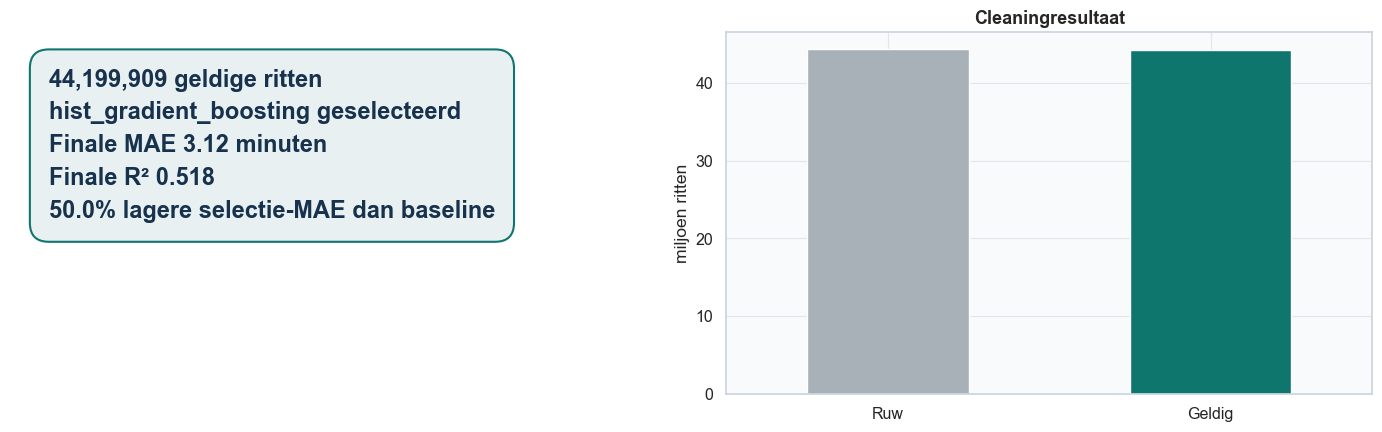

In [3]:
winner = metrics.loc[metrics.model == bundle["model_name"]].iloc[0]
baseline = metrics.loc[metrics.model == "median_baseline"].iloc[0]
improvement = 100 * (baseline.mae_minutes - winner.mae_minutes) / baseline.mae_minutes
final_metrics = pd.Series(bundle["metrics"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].axis("off")
axes[0].set_facecolor(COLORS["light"])
kpi_text = (
    f"{audit['output_rows']:,} geldige ritten\n"
    f"{bundle['model_name']} geselecteerd\n"
    f"Finale MAE {final_metrics.mae_minutes:.2f} minuten\n"
    f"Finale R² {final_metrics.r2:.3f}\n"
    f"{improvement:.1f}% lagere selectie-MAE dan baseline"
)
axes[0].text(
    0.06, 0.90, kpi_text, va="top", fontsize=17, linespacing=1.55,
    color=COLORS["navy"], weight="semibold",
    bbox={"boxstyle": "round,pad=0.8", "facecolor": COLORS["light"],
          "edgecolor": COLORS["teal"], "linewidth": 1.5},
)
cleaning = pd.Series(
    {"Ruw": audit["input_rows"], "Geldig": audit["output_rows"]}
) / 1_000_000
cleaning.plot.bar(ax=axes[1], color=[COLORS["grey"], COLORS["teal"]])
axes[1].set(title="Cleaningresultaat", ylabel="miljoen ritten", xlabel="")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
display(
    metrics.style
    .format({
        "mae_minutes": "{:.2f}", "rmse_minutes": "{:.2f}",
        "median_ae_minutes": "{:.2f}", "r2": "{:.3f}",
    })
    .background_gradient(subset=["r2"], cmap="YlGnBu")
)

## Alle modelfeatures

De tabel maakt zichtbaar welke variabelen ruw, afgeleid of extern zijn en hoeveel waarden in de dashboardsteekproef ontbreken.

In [4]:
feature_catalog = pd.DataFrame(
    [
        ("rideable_type", "categorisch", "bron", "Type fiets"),
        ("member_casual", "categorisch", "bron", "Member of casual rider"),
        ("start_station_id", "categorisch", "bron", "Gepland startstation"),
        ("end_station_id", "categorisch", "planning", "Vooraf gekozen bestemming"),
        ("start_lat", "numeriek", "bron", "Latitude start"),
        ("start_lng", "numeriek", "bron", "Longitude start"),
        ("end_lat", "numeriek", "planning", "Latitude bestemming"),
        ("end_lng", "numeriek", "planning", "Longitude bestemming"),
        ("direct_distance_km", "numeriek", "afgeleid", "Hemelsbrede Haversine-afstand"),
        ("grid_distance_km", "numeriek", "afgeleid", "Afstand volgens de gedraaide NYC-gridassen"),
        ("delta_lat", "numeriek", "afgeleid", "Noord-zuidverplaatsing"),
        ("delta_lng", "numeriek", "afgeleid", "Oost-westverplaatsing"),
        ("bearing_sin", "cyclisch", "afgeleid", "Sinus van reisrichting"),
        ("bearing_cos", "cyclisch", "afgeleid", "Cosinus van reisrichting"),
        ("route_typical_minutes", "numeriek", "historisch", "Gesmoothde eerdere duur voor start-eindpaar"),
        ("route_history_log_count", "numeriek", "historisch", "Logaritme van eerdere ritten op de route"),
        ("start_typical_minutes", "numeriek", "historisch", "Gesmoothde eerdere duur vanaf startstation"),
        ("end_typical_minutes", "numeriek", "historisch", "Gesmoothde eerdere duur naar eindstation"),
        ("start_hour_sin", "cyclisch", "afgeleid", "Sinus van vertrekuur"),
        ("start_hour_cos", "cyclisch", "afgeleid", "Cosinus van vertrekuur"),
        ("weekday_sin", "cyclisch", "afgeleid", "Sinus van weekdag"),
        ("weekday_cos", "cyclisch", "afgeleid", "Cosinus van weekdag"),
        ("month_sin", "cyclisch", "afgeleid", "Sinus van maand"),
        ("month_cos", "cyclisch", "afgeleid", "Cosinus van maand"),
        ("is_weekend", "binair", "afgeleid", "Weekendindicator"),
        ("is_holiday", "binair", "afgeleid", "Amerikaanse federale feestdag"),
        ("temperature_2m", "numeriek", "extern weer", "Temperatuur in °C"),
        ("relative_humidity_2m", "numeriek", "extern weer", "Relatieve luchtvochtigheid in %"),
        ("precipitation", "numeriek", "extern weer", "Neerslag in mm"),
        ("wind_speed_10m", "numeriek", "extern weer", "Windsnelheid in km/u"),
    ],
    columns=["feature", "type", "herkomst", "betekenis"],
)
missing = feature_frame.isna().mean().mul(100)
feature_catalog["missing_pct"] = feature_catalog.feature.map(missing).round(2)
display(feature_catalog.style.format({"missing_pct": "{:.2f}%"}))

,feature,type,herkomst,betekenis,missing_pct
0,rideable_type,categorisch,bron,Type fiets,0.00%
1,member_casual,categorisch,bron,Member of casual rider,0.00%
2,start_station_id,categorisch,bron,Gepland startstation,0.00%
3,end_station_id,categorisch,planning,Vooraf gekozen bestemming,0.00%
4,start_lat,numeriek,bron,Latitude start,0.00%
5,start_lng,numeriek,bron,Longitude start,0.00%
6,end_lat,numeriek,planning,Latitude bestemming,0.19%
7,end_lng,numeriek,planning,Longitude bestemming,0.19%
8,direct_distance_km,numeriek,afgeleid,Hemelsbrede Haversine-afstand,0.19%
9,grid_distance_km,numeriek,afgeleid,Afstand volgens de gedraaide NYC-gridassen,0.19%


## Wie rijdt en wanneer?

Volume, typische ritduur en gebruikersmix vertellen elk een ander deel van het verhaal.

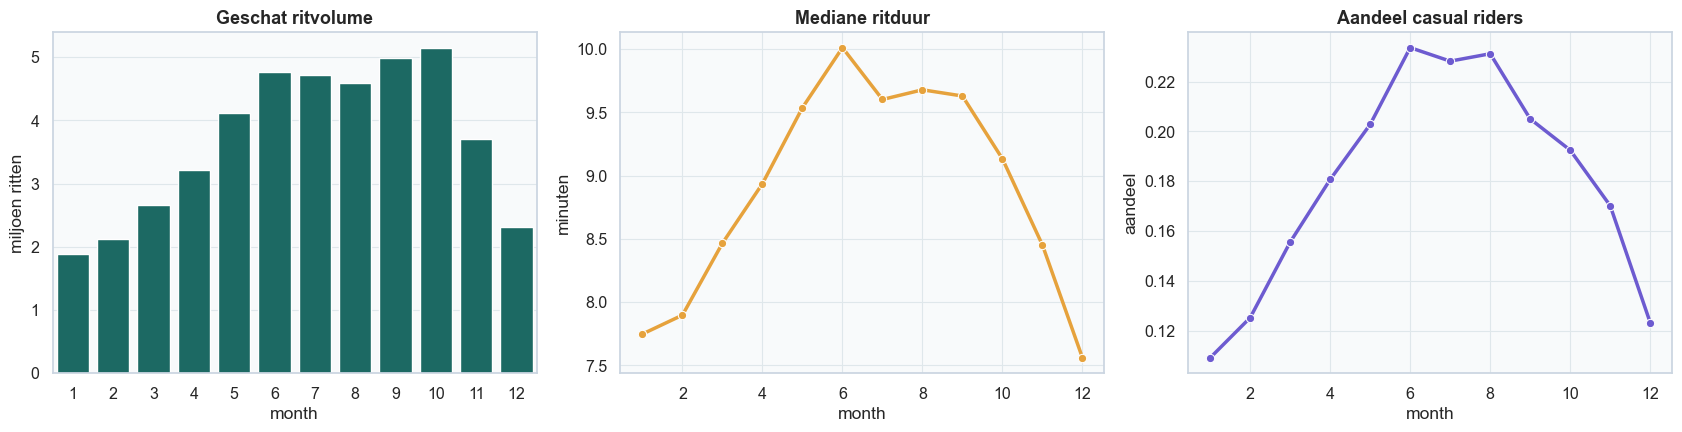

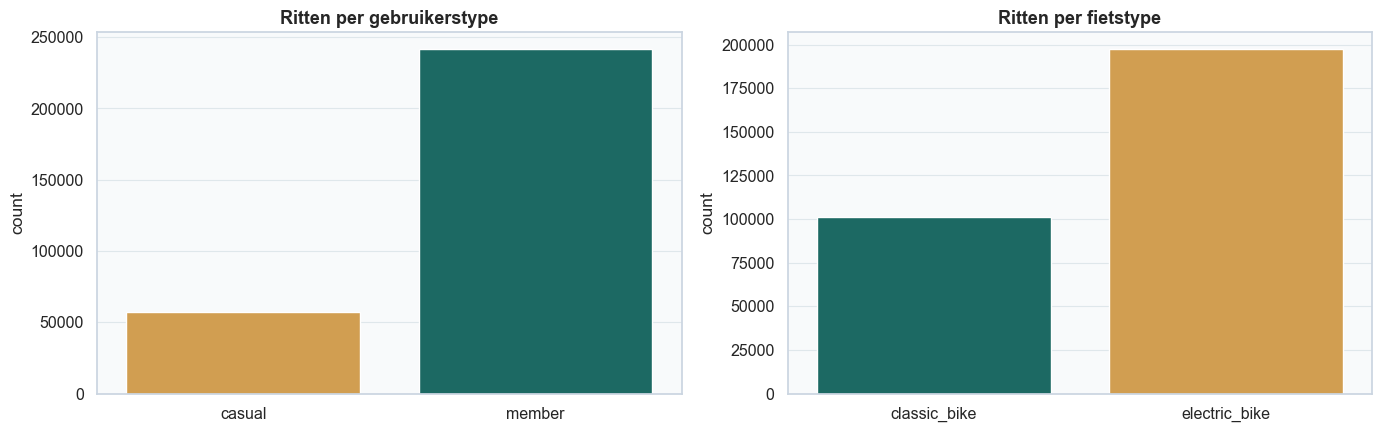

In [5]:
plot_data = dashboard.copy()
plot_data["month"] = plot_data.started_at.dt.month
plot_data["hour"] = plot_data.started_at.dt.hour
plot_data["weekday"] = plot_data.started_at.dt.day_name()
month = plot_data.groupby("month").agg(
    rides=(TARGET, "size"), median_minutes=(TARGET, "median"),
    casual_share=("member_casual", lambda s: (s == "casual").mean()),
).reset_index()
month["estimated_million_rides"] = (
    month.rides * audit["output_rows"] / len(plot_data) / 1_000_000
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.barplot(data=month, x="month", y="estimated_million_rides", ax=axes[0], color=COLORS["teal"])
sns.lineplot(data=month, x="month", y="median_minutes", marker="o", ax=axes[1], color=COLORS["gold"], linewidth=2.5)
sns.lineplot(data=month, x="month", y="casual_share", marker="o", ax=axes[2], color=COLORS["purple"], linewidth=2.5)
axes[0].set(title="Geschat ritvolume", ylabel="miljoen ritten")
axes[1].set(title="Mediane ritduur", ylabel="minuten")
axes[2].set(title="Aandeel casual riders", ylabel="aandeel")
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(
    data=plot_data, x="member_casual", hue="member_casual",
    palette={"member": COLORS["teal"], "casual": COLORS["gold"]},
    legend=False, ax=axes[0],
)
bike_levels = list(plot_data["rideable_type"].dropna().unique())
bike_palette = dict(zip(bike_levels, SERIES_PALETTE, strict=False))
sns.countplot(
    data=plot_data, x="rideable_type", hue="rideable_type",
    palette=bike_palette, legend=False, ax=axes[1],
)
axes[0].set(title="Ritten per gebruikerstype", xlabel="")
axes[1].set(title="Ritten per fietstype", xlabel="")
plt.tight_layout()

## Bestemming en afstand

De rechte lijn is geen echte fietsroute, maar vormt wel een sterke, vooraf berekenbare ondergrens voor de af te leggen afstand.

,direct_distance_km,n,median_minutes,distance_band
0,"[0.0, 0.5)",32336,2.795400,"[0.0, 0.5)"
1,"[0.5, 1.0)",61605,4.516833,"[0.5, 1.0)"
2,"[1.0, 2.0)",95551,7.904817,"[1.0, 2.0)"
3,"[2.0, 3.0)",48319,12.536333,"[2.0, 3.0)"
4,"[3.0, 5.0)",40479,18.063333,"[3.0, 5.0)"
5,"[5.0, 8.0)",16144,26.630550,"[5.0, 8.0)"
6,"[8.0, 15.0)",3566,38.877758,"[8.0, 15.0)"
7,"[15.0, inf)",96,64.117133,"[15.0, inf)"


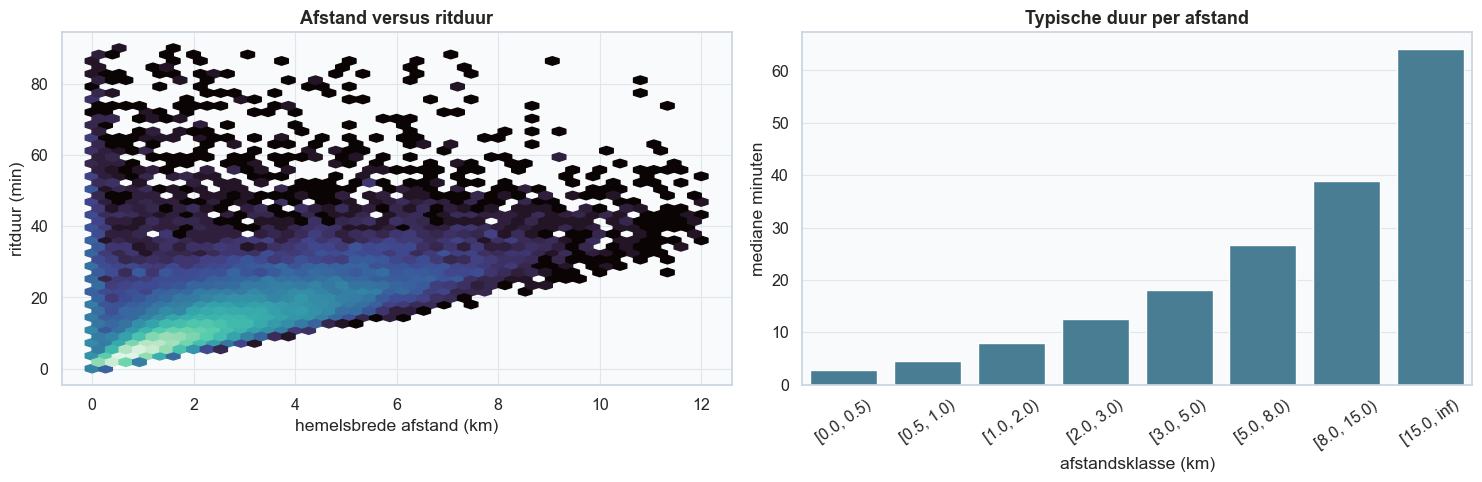

In [6]:
route_plot = plot_data.sample(min(40_000, len(plot_data)), random_state=42)
distance_bins = pd.cut(
    plot_data.direct_distance_km,
    bins=[0, 0.5, 1, 2, 3, 5, 8, 15, np.inf],
    right=False,
)
distance_summary = plot_data.groupby(distance_bins, observed=True).agg(
    n=(TARGET, "size"), median_minutes=(TARGET, "median")
).reset_index()
distance_summary["distance_band"] = distance_summary.direct_distance_km.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hexbin(
    route_plot.direct_distance_km, route_plot[TARGET], gridsize=45,
    mincnt=1, bins="log", cmap="mako", extent=(0, 12, 0, 90),
)
axes[0].set(xlabel="hemelsbrede afstand (km)", ylabel="ritduur (min)", title="Afstand versus ritduur")
sns.barplot(data=distance_summary, x="distance_band", y="median_minutes", ax=axes[1], color=COLORS["sky"])
axes[1].set(xlabel="afstandsklasse (km)", ylabel="mediane minuten", title="Typische duur per afstand")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
display(distance_summary)

## Weerrelaties

Deze grafieken tonen associaties binnen gerealiseerde ritten. Ze bewijzen niet dat weer een verandering in ritduur veroorzaakt.

temperature_band       n  median_minutes temperature_label  \
analyse                                                                    
temperatuur 0     (-30.0, 0.0]   12154        7.207417          (-30, 0]   
            1       (0.0, 5.0]   23988        7.607867            (0, 5]   
            2      (5.0, 10.0]   34104        8.120342           (5, 10]   
            3     (10.0, 15.0]   40394        8.790375          (10, 15]   
            4     (15.0, 20.0]   49986        9.178292          (15, 20]   
            5     (20.0, 25.0]   69877        9.796683          (20, 25]   
            6     (25.0, 30.0]   53598       10.053058          (25, 30]   
            7     (30.0, 50.0]   14545        9.939217          (30, 50]   
regen       0              NaN  266854        9.123583               NaN   
            1              NaN   31795        8.606583               NaN   

                   rain  
analyse                  
temperatuur 0       NaN  
            1       NaN  
            2       NaN  
            3       NaN  
            4       NaN  
            5       NaN  
            6       NaN  
            7       NaN  
regen       0     droog  
            1  neerslag

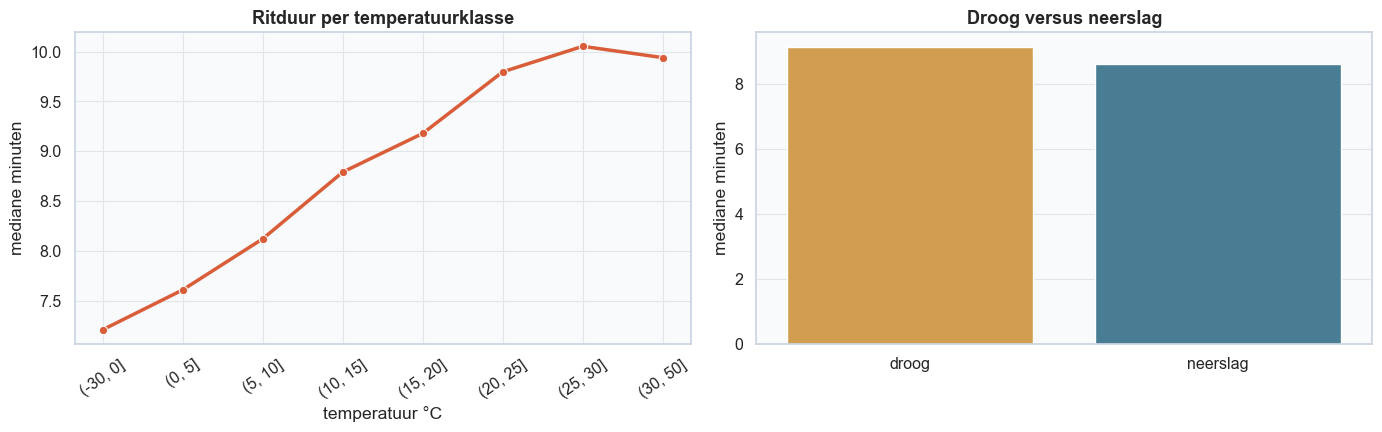

In [7]:
weather_plot = plot_data.copy()
weather_plot["temperature_band"] = pd.cut(
    weather_plot.temperature_2m, [-30, 0, 5, 10, 15, 20, 25, 30, 50]
)
weather_plot["rain"] = np.where(weather_plot.precipitation > 0, "neerslag", "droog")
temperature = weather_plot.groupby("temperature_band", observed=True).agg(
    n=(TARGET, "size"), median_minutes=(TARGET, "median")
).reset_index()
temperature["temperature_label"] = temperature.temperature_band.astype(str)
rain = weather_plot.groupby("rain").agg(
    n=(TARGET, "size"), median_minutes=(TARGET, "median")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(
    data=temperature, x="temperature_label", y="median_minutes",
    marker="o", color=COLORS["coral"], linewidth=2.5, ax=axes[0],
)
rain_palette = {"droog": COLORS["gold"], "neerslag": COLORS["sky"]}
sns.barplot(
    data=rain, x="rain", y="median_minutes", hue="rain",
    palette=rain_palette, legend=False, ax=axes[1],
)
axes[0].set(title="Ritduur per temperatuurklasse", xlabel="temperatuur °C", ylabel="mediane minuten")
axes[0].tick_params(axis="x", rotation=35)
axes[1].set(title="Droog versus neerslag", xlabel="", ylabel="mediane minuten")
plt.tight_layout()
display(pd.concat({"temperatuur": temperature, "regen": rain}, names=["analyse"]))

## Modelvergelijking op selectievalidatie

De finale hold-out blijft buiten de modelkeuze. Van de kandidaten binnen 0,10 minuut van de beste validatie-MAE kiezen we de hoogste validatie-R²; daarna wordt alleen de winnaar opnieuw getraind en één keer op de eindtest gemeten.

,split,mae_minutes,r2
0,training,3.774676,0.465125
1,finale Q4-hold-out,3.120821,0.518106


,month,rows,mae_minutes,rmse_minutes,median_ae_minutes,r2
0,2024-10,64000,3.366531,8.154537,1.580344,0.488463
1,2024-11,83774,3.203923,7.360186,1.613322,0.520521
2,2024-12,52226,2.686417,6.239150,1.375612,0.554167


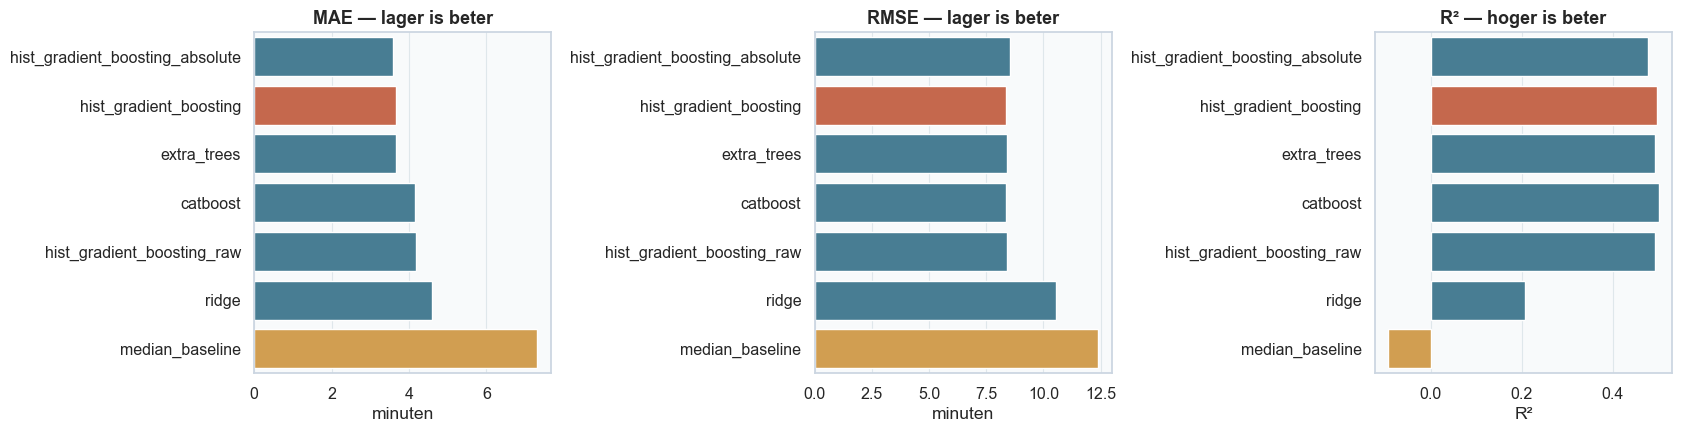

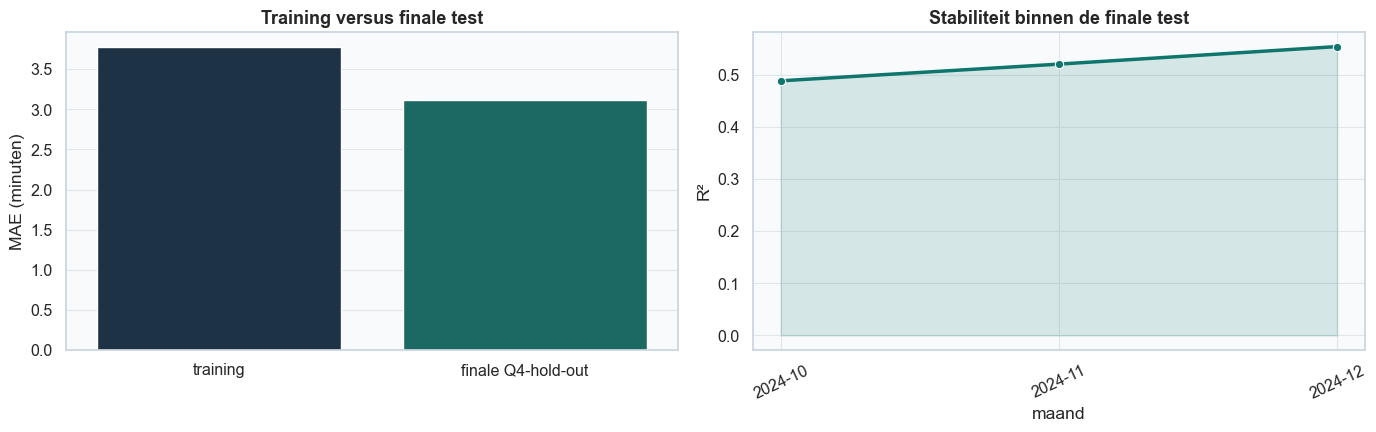

In [8]:
model_colors = {
    model: (
        COLORS["coral"] if model == bundle["model_name"]
        else COLORS["gold"] if model == "median_baseline"
        else COLORS["sky"]
    )
    for model in metrics.model
}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for axis, metric_name in zip(axes, ["mae_minutes", "rmse_minutes", "r2"]):
    sns.barplot(
        data=metrics, y="model", x=metric_name, hue="model",
        palette=model_colors, legend=False, ax=axis,
    )
axes[0].set(title="MAE — lager is beter", xlabel="minuten", ylabel="")
axes[1].set(title="RMSE — lager is beter", xlabel="minuten", ylabel="")
axes[2].set(title="R² — hoger is beter", xlabel="R²", ylabel="")
plt.tight_layout()

generalization = pd.DataFrame([
    {
        "split": "training",
        "mae_minutes": bundle["training_metrics"]["mae_minutes"],
        "r2": bundle["training_metrics"]["r2"],
    },
    {
        "split": "finale Q4-hold-out",
        "mae_minutes": bundle["metrics"]["mae_minutes"],
        "r2": bundle["metrics"]["r2"],
    },
])
monthly = pd.DataFrame(bundle["monthly_holdout_metrics"])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(
    data=generalization, x="split", y="mae_minutes", hue="split",
    palette={"training": COLORS["navy"], "finale Q4-hold-out": COLORS["teal"]},
    legend=False, ax=axes[0],
)
sns.lineplot(
    data=monthly, x="month", y="r2", marker="o", ax=axes[1],
    color=COLORS["teal"], linewidth=2.5,
)
axes[1].fill_between(monthly["month"], monthly["r2"], alpha=0.15, color=COLORS["teal"])
axes[0].set(title="Training versus finale test", xlabel="", ylabel="MAE (minuten)")
axes[1].set(title="Stabiliteit binnen de finale test", xlabel="maand", ylabel="R²")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
display(generalization, monthly)

## Permutation importance

Iedere feature wordt afzonderlijk door elkaar geschud. De toename in MAE laat zien
hoeveel voorspellende informatie het getrainde model daardoor verliest. Gecorreleerde
features kunnen elkaars belang verdelen; dit is dus geen causale ranglijst.

,feature,mae_increase,std
8,direct_distance_km,4.760,0.016
0,rideable_type,0.571,0.009
1,member_casual,0.218,0.011
13,bearing_cos,0.073,0.005
14,route_typical_minutes,0.072,0.005
12,bearing_sin,0.067,0.002
7,end_lng,0.048,0.003
18,start_hour_sin,0.041,0.005
11,delta_lng,0.039,0.001
5,start_lng,0.039,0.003


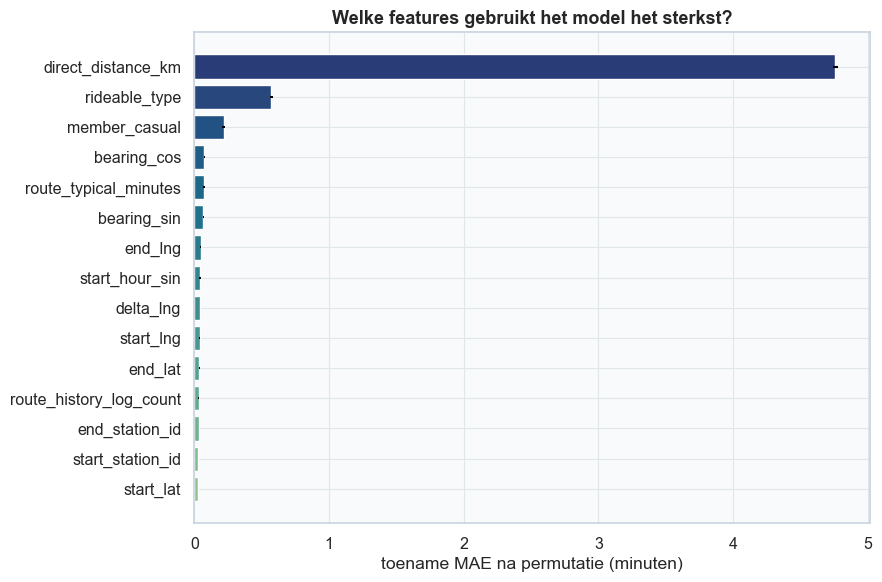

In [9]:
importance_sample = holdout.sample(min(12_000, len(holdout)), random_state=42)
permutation = permutation_importance(
    bundle["model"], importance_sample[model_features], importance_sample[TARGET],
    scoring="neg_mean_absolute_error", n_repeats=3, random_state=42, n_jobs=1,
)
importance = pd.DataFrame({
    "feature": model_features,
    "mae_increase": permutation.importances_mean,
    "std": permutation.importances_std,
}).sort_values("mae_increase", ascending=False)

top = importance.head(15).sort_values("mae_increase")
plt.figure(figsize=(9, 6))
importance_colors = sns.color_palette("crest", n_colors=len(top))
plt.barh(top.feature, top.mae_increase, xerr=top["std"], color=importance_colors)
plt.xlabel("toename MAE na permutatie (minuten)")
plt.title("Welke features gebruikt het model het sterkst?")
plt.tight_layout()
display(importance.style.format({"mae_increase": "{:.3f}", "std": "{:.3f}"}))

## Werkelijk versus voorspeld en residuen

Een goed model ligt rond de diagonaal. Positieve residuen betekenen overschatting; negatieve residuen onderschatting.

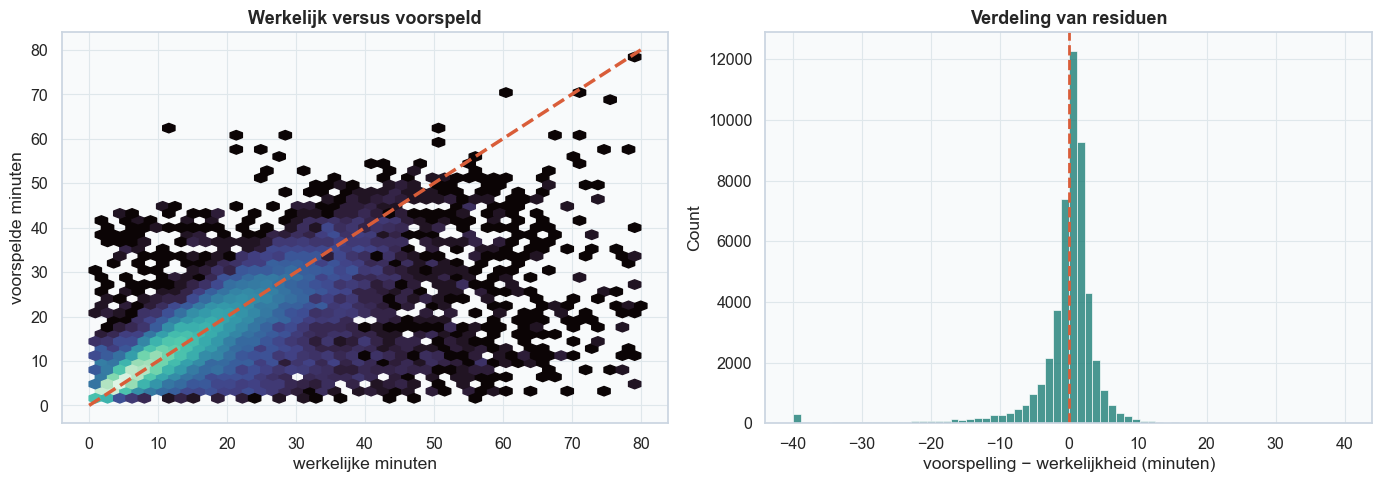

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hexbin(
    holdout[TARGET], holdout.prediction, gridsize=45, mincnt=1,
    bins="log", cmap="mako", extent=(0, 80, 0, 80),
)
axes[0].plot([0, 80], [0, 80], "--", color=COLORS["coral"], linewidth=2.5)
axes[0].set(xlabel="werkelijke minuten", ylabel="voorspelde minuten", title="Werkelijk versus voorspeld")
sns.histplot(holdout.error.clip(-40, 40), bins=70, ax=axes[1], color=COLORS["teal"])
axes[1].axvline(0, color=COLORS["coral"], linestyle="--", linewidth=2)
axes[1].set(xlabel="voorspelling − werkelijkheid (minuten)", title="Verdeling van residuen")
plt.tight_layout()

## Prestaties per subgroep

Deze controle voorkomt dat een goede totaalscore een structureel zwakke gebruikersgroep verbergt.

,dimensie,groep,n,mae,median_ae,bias
0,member_casual,casual,8108,6.09,3.05,-1.37
1,member_casual,member,41892,2.54,1.36,-0.41
2,rideable_type,classic_bike,15951,3.15,1.41,-0.87
3,rideable_type,electric_bike,34049,3.10,1.58,-0.42
4,weekpart,weekend,12494,3.79,1.80,-0.72
5,weekpart,werkdag,37506,2.89,1.44,-0.51
6,weather,droog,47068,3.15,1.54,-0.57
7,weather,neerslag,2932,2.61,1.32,-0.46


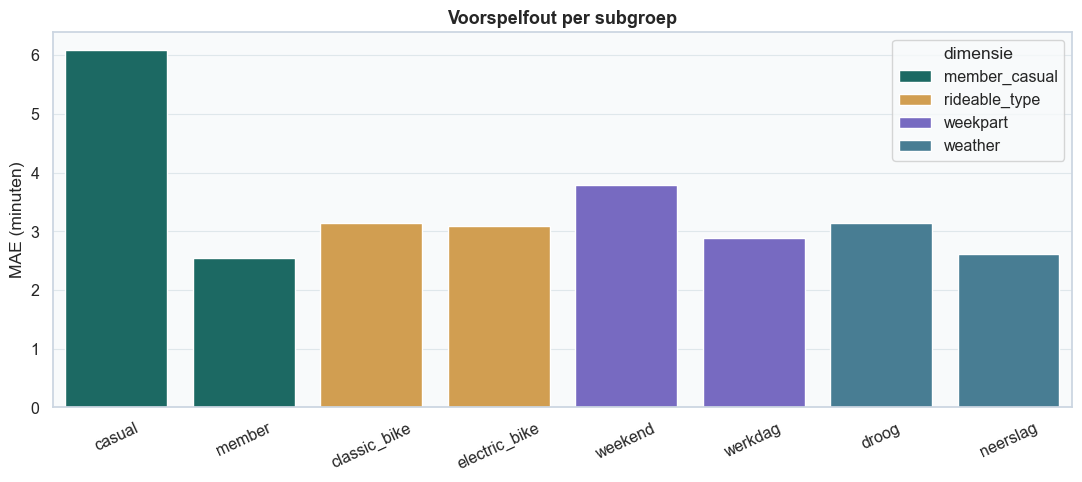

In [11]:
subgroup_frame = holdout.copy()
subgroup_frame["weekpart"] = np.where(subgroup_frame.is_weekend == 1, "weekend", "werkdag")
subgroup_frame["weather"] = np.where(subgroup_frame.precipitation > 0, "neerslag", "droog")
subgroup_tables = []
for column in ["member_casual", "rideable_type", "weekpart", "weather"]:
    part = subgroup_frame.groupby(column, observed=True).agg(
        n=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        median_ae=("absolute_error", "median"),
        bias=("error", "mean"),
    ).reset_index(names="groep")
    part.insert(0, "dimensie", column)
    subgroup_tables.append(part)
subgroup = pd.concat(subgroup_tables, ignore_index=True)

plt.figure(figsize=(11, 5))
subgroup_palette = {
    "member_casual": COLORS["teal"],
    "rideable_type": COLORS["gold"],
    "weekpart": COLORS["purple"],
    "weather": COLORS["sky"],
}
sns.barplot(data=subgroup, x="groep", y="mae", hue="dimensie", palette=subgroup_palette)
plt.ylabel("MAE (minuten)")
plt.xlabel("")
plt.title("Voorspelfout per subgroep")
plt.xticks(rotation=25)
plt.tight_layout()
display(subgroup.style.format({"mae": "{:.2f}", "median_ae": "{:.2f}", "bias": "{:.2f}"}))

## Concrete fouten

De grootste fouten zijn productmatig vaak leerzamer dan het gemiddelde.

In [12]:
example_columns = [
    "started_at", "member_casual", "rideable_type", "direct_distance_km",
    "temperature_2m", TARGET, "prediction", "error", "absolute_error",
]
print("Grootste fouten")
display(holdout.nlargest(15, "absolute_error")[example_columns])
print("Typische goede voorspellingen")
display(holdout.nsmallest(10, "absolute_error")[example_columns])

Grootste fouten


,started_at,member_casual,rideable_type,direct_distance_km,temperature_2m,duration_minutes,prediction,error,absolute_error
291422,2024-12-14 19:56:19.119,casual,classic_bike,0.630123,-1.9,175.097767,9.854208,-165.243559,165.243559
270582,2024-11-13 14:03:10.212,casual,electric_bike,0.587157,8.6,174.015350,9.991878,-164.023472,164.023472
251450,2024-10-26 02:14:51.919,casual,classic_bike,0.865404,10.8,166.795050,6.826517,-159.968533,159.968533
275828,2024-11-19 11:10:39.770,casual,classic_bike,2.719548,11.0,176.184717,22.171252,-154.013465,154.013465
247711,2024-10-22 21:57:39.069,casual,classic_bike,0.875606,17.4,148.316433,6.168498,-142.147936,142.147936
248316,2024-10-23 14:28:59.580,casual,electric_bike,2.597934,25.2,149.292917,11.833941,-137.458975,137.458975
295676,2024-12-22 15:36:27.164,casual,electric_bike,5.226359,-7.5,162.011567,29.172231,-132.839335,132.839335
257064,2024-10-31 09:47:52.140,casual,classic_bike,3.581727,15.5,159.608500,27.459508,-132.148992,132.148992
244392,2024-10-19 21:27:46.847,casual,electric_bike,0.211067,12.1,139.573183,10.798855,-128.774328,128.774328
244984,2024-10-20 14:54:02.658,casual,classic_bike,0.000000,23.6,148.315850,20.732867,-127.582983,127.582983


Typische goede voorspellingen


,started_at,member_casual,rideable_type,direct_distance_km,temperature_2m,duration_minutes,prediction,error,absolute_error
284139,2024-12-03 06:56:43.919,member,electric_bike,1.763245,-2.2,8.059067,8.059001,-0.000066,0.000066
294993,2024-12-20 12:54:29.484,member,electric_bike,1.042730,1.8,6.038917,6.038845,-0.000071,0.000071
282891,2024-11-30 15:48:07.870,member,electric_bike,3.241008,3.5,15.385933,15.386005,0.000072,0.000072
251380,2024-10-25 23:37:39.659,member,classic_bike,0.807589,12.5,5.806550,5.806633,0.000083,0.000083
241376,2024-10-17 09:19:25.188,member,classic_bike,1.342042,7.3,9.609200,9.609346,0.000146,0.000146
249187,2024-10-24 08:27:17.595,member,classic_bike,1.670865,14.5,11.156533,11.156690,0.000156,0.000156
250733,2024-10-25 14:48:57.517,member,classic_bike,0.380969,17.1,2.788633,2.788810,0.000176,0.000176
241236,2024-10-17 07:34:06.540,member,electric_bike,0.592041,3.6,3.032400,3.032618,0.000218,0.000218
239024,2024-10-14 19:12:17.664,member,electric_bike,0.547334,10.6,3.425900,3.426130,0.000230,0.000230
260987,2024-11-03 16:56:26.083,member,electric_bike,6.864309,13.3,28.716083,28.715814,-0.000270,0.000270


## Automatisch eindbesluit

Deze cel vat de actuele artifacts samen; de tekst verandert dus mee na een nieuwe training.

In [13]:
top_feature = importance.iloc[0]
weakest = subgroup.loc[subgroup.mae.idxmax()]
display(Markdown(
    f'''
    Het geselecteerde **{bundle['model_name']}**-model behaalt op de aparte finale
    hold-out een MAE van **{final_metrics.mae_minutes:.2f} minuten** en R² van
    **{final_metrics.r2:.3f}**. Op de selectievalidatie was de MAE
    **{winner.mae_minutes:.2f} minuten**, tegenover **{baseline.mae_minutes:.2f}** voor
    de mediaanbaseline: een verbetering van **{improvement:.1f}%**. De sterkste
    feature in deze permutation-analyse is **`{top_feature.feature}`**; permuteren
    verhoogt de MAE met ongeveer **{top_feature.mae_increase:.2f} minuten**. De zwakste
    gerapporteerde subgroep is **{weakest.groep}** met MAE **{weakest.mae:.2f} minuten**.

    Dit blijft een schatting: de rechte-lijnafstand vervangt geen echte fietsroute en
    verkeer, evenementen, routekeuze en actuele infrastructuur ontbreken.
    '''
))


    Het geselecteerde **hist_gradient_boosting**-model behaalt op de aparte finale
    hold-out een MAE van **3.12 minuten** en R² van
    **0.518**. Op de selectievalidatie was de MAE
    **3.66 minuten**, tegenover **7.31** voor
    de mediaanbaseline: een verbetering van **50.0%**. De sterkste
    feature in deze permutation-analyse is **`direct_distance_km`**; permuteren
    verhoogt de MAE met ongeveer **4.76 minuten**. De zwakste
    gerapporteerde subgroep is **casual** met MAE **6.09 minuten**.

    Dit blijft een schatting: de rechte-lijnafstand vervangt geen echte fietsroute en
    verkeer, evenementen, routekeuze en actuele infrastructuur ontbreken.
    